1. Viết hàm load_data() để tải dữ liệu lên ứng dụng. Sau đó, hiển thị ra màn hình 10 dòng
đầu tiên.

In [7]:
import pandas as pd

def load_data(file_path):
    """
    Hàm tải dữ liệu từ file CSV
    """
    df = pd.read_csv(file_path)
    return df

# Gọi hàm và hiển thị 10 dòng đầu
df = load_data("titanic_disaster.csv")
print(df.head(10))


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timothy J    male  54

In [ ]:
2. Thống kê dữ liệu thiếu trên các biến số và trực quan hóa dữ liệu thiếu bằng biểu đồ (Heat
map). Hãy cho nhận xét về tình trạng thiếu dữ liệu Age, Cabin và Embarked

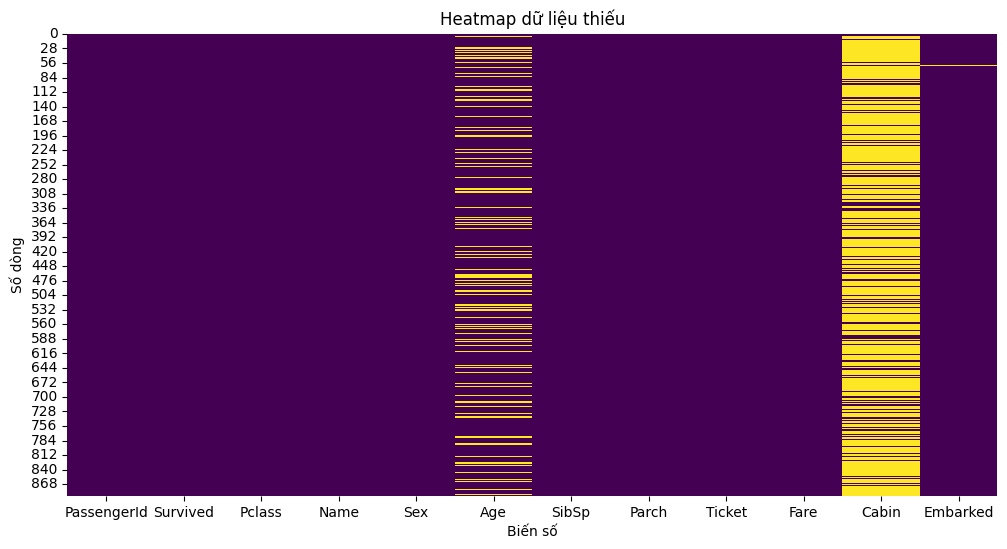


Tỷ lệ (%) dữ liệu thiếu:
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64
Số lượng dữ liệu thiếu trên từng biến:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Heatmap dữ liệu thiếu")
plt.xlabel("Biến số")
plt.ylabel("Số dòng")
plt.show()

missing_percent = df.isnull().mean() * 100
print("\nTỷ lệ (%) dữ liệu thiếu:")
print(missing_percent)

# Thống kê số lượng dữ liệu thiếu
missing_count = df.isnull().sum()
print("Số lượng dữ liệu thiếu trên từng biến:")
print(missing_count)


3. Xử lý tên cột tên Name, tách ra làm 2 cột: firstName và secondName. Lưu ý: Sau khi
tách cột xong thì xóa luôn cột Name


In [11]:
# Tách họ (secondName): phần trước dấu phẩy
df['secondName'] = df['Name'].str.split(',', expand=True)[0]

# Tách tên riêng (firstName): bỏ danh xưng (Mr., Mrs., Miss...)
df['firstName'] = (
    df['Name']
    .str.split(',', expand=True)[1]     # phần sau dấu phẩy
    .str.split('.', expand=True)[1]     # bỏ danh xưng
    .str.strip()                        # xóa khoảng trắng
    .str.split(' ', expand=True)[0]     # lấy tên đầu tiên
)

# Xóa cột Name
df.drop(columns=['Name'], inplace=True)

# Kiểm tra kết quả
print(df[['firstName', 'secondName']].head(10))


  firstName secondName
0      Owen     Braund
1      John    Cumings
2     Laina  Heikkinen
3   Jacques   Futrelle
4   William      Allen
5     James      Moran
6   Timothy   McCarthy
7     Gosta    Palsson
8     Oscar    Johnson
9  Nicholas     Nasser


4. Xứ lý rút gọn kích thước dữ liệu trên cột Sex như sau: thay thế male → M và female → F

In [12]:
df['Sex'] = df['Sex'].replace({
    'male': 'M',
    'female': 'F'
})
print(df['Sex'].value_counts())

Sex
M    577
F    314
Name: count, dtype: int64


5. Xử lý dữ liệu thiếu trên biến Age bằng cách thay thế bằng giá trị trung bình tuổi: Hãy đưa
ra quyết định dùng giá trị trung bình tuổi toàn bộ hành khách hay theo từng nhóm hạng
vé (hạng hành khách: Pclass). Ta tiến hành làm các bước sau
a. Sử dụng Seaborn để vẽ biểu đồ (Box plot) trực quan dữ liệu để xác định phân
phối tuổi trên từng hạng hành khách. Nhận xét về tuổi trung bình giữa các nhóm
hành khách. Từ đó đưa ra quyết định cách thay thế giá trị tuổi bị thiếu.
BÀI TẬP THỰC HÀNH MÔN NHẬP MÔN PHÂN TÍCH DỮ LIỆU VÀ HỌC SÂU
12
b. Tiến hành thay thế giá trị Age bị thiếu. Sau đó, hiển thị kết quả dạng bảng và trực
quan dữ liệu đã xử lý thiếu cho cột’Age’ bằng biểu đồ Heat map.

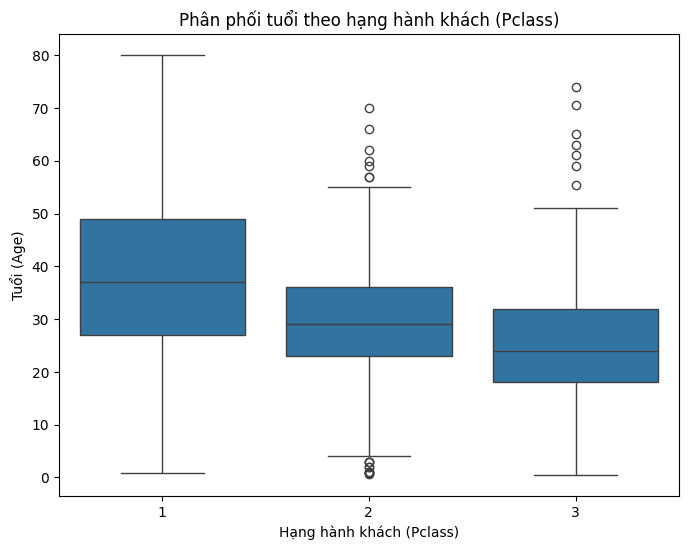

   Pclass       Age
0       3  22.00000
1       1  38.00000
2       3  26.00000
3       1  35.00000
4       3  35.00000
5       3  25.14062
6       1  54.00000
7       3   2.00000
8       3  27.00000
9       2  14.00000


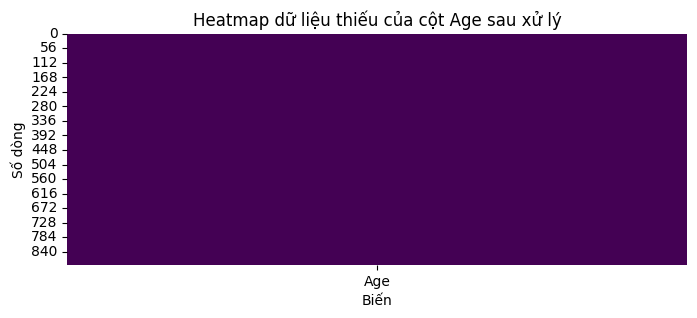

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# ===== a. Box plot: phân phối tuổi theo hạng hành khách =====
plt.figure(figsize=(8, 6))
sns.boxplot(x='Pclass', y='Age', data=df)
plt.title('Phân phối tuổi theo hạng hành khách (Pclass)')
plt.xlabel('Hạng hành khách (Pclass)')
plt.ylabel('Tuổi (Age)')
plt.show()

# ===== b. Thay thế giá trị Age bị thiếu theo từng Pclass =====
df['Age'] = df.groupby('Pclass')['Age'].transform(
    lambda x: x.fillna(x.mean())
)

# Hiển thị kết quả dạng bảng
print(df[['Pclass', 'Age']].head(10))

# ===== Heatmap dữ liệu thiếu của cột Age sau xử lý =====
plt.figure(figsize=(8, 3))
sns.heatmap(df[['Age']].isnull(), cbar=False, cmap='viridis')
plt.title("Heatmap dữ liệu thiếu của cột Age sau xử lý")
plt.xlabel("Biến")
plt.ylabel("Số dòng")
plt.show()


6. Xây dựng biến số Agegroup có thang đo thứ tự được ánh xạ theo thang đo khoảng dựa
trên độ tuổi của hành khách như sau: (age =< 12] → Kid; (12, 18]: Teen, (18, 60]: Adult
và ( age > 60): Older

In [14]:
import numpy as np
import pandas as pd

# Tạo biến Agegroup theo các khoảng tuổi
bins = [0, 12, 18, 60, np.inf]
labels = ['Kid', 'Teen', 'Adult', 'Older']

df['Agegroup'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Ánh xạ thang đo thứ tự (ordinal)
agegroup_mapping = {
    'Kid': 1,
    'Teen': 2,
    'Adult': 3,
    'Older': 4
}

df['Agegroup_ordinal'] = df['Agegroup'].map(agegroup_mapping)

# Kiểm tra kết quả
print(df[['Age', 'Agegroup', 'Agegroup_ordinal']].head(10))
print(df['Agegroup'].value_counts())


        Age Agegroup Agegroup_ordinal
0  22.00000    Adult                3
1  38.00000    Adult                3
2  26.00000    Adult                3
3  35.00000    Adult                3
4  35.00000    Adult                3
5  25.14062    Adult                3
6  54.00000    Adult                3
7   2.00000      Kid                1
8  27.00000    Adult                3
9  14.00000     Teen                2
Agegroup
Adult    730
Teen      70
Kid       69
Older     22
Name: count, dtype: int64


7. Tiến hành thêm đặc trưng về danh xưng (namePrefix) trong xã hội bằng cách tách Mr,
Mrs, Miss, Master ra khỏi “secondName”

In [15]:
import pandas as pd

df_raw = pd.read_csv("titanic_disaster.csv")

# Tách danh xưng xã hội
df['namePrefix'] = (
    df_raw['Name']
    .str.extract(r',\s*([^\.]+)\.', expand=False)
)

# Chỉ giữ 4 danh xưng chính, còn lại gom vào Other
df['namePrefix'] = df['namePrefix'].where(
    df['namePrefix'].isin(['Mr', 'Mrs', 'Miss', 'Master']),
    'Other'
)

# Kiểm tra kết quả
print(df['namePrefix'].value_counts())
print(df[['secondName', 'namePrefix']].head(10))


namePrefix
Mr        517
Miss      182
Mrs       125
Master     40
Other      27
Name: count, dtype: int64
  secondName namePrefix
0     Braund         Mr
1    Cumings        Mrs
2  Heikkinen       Miss
3   Futrelle        Mrs
4      Allen         Mr
5      Moran         Mr
6   McCarthy         Mr
7    Palsson     Master
8    Johnson        Mrs
9     Nasser        Mrs


8. Khai thác thêm thông tin số lượng thành viên đi theo nhóm thân quen (familySize) đối
với mỗi hành khách trên chuyến hải trình; family size = 1+ SibSp + Parch


In [16]:
# Tạo đặc trưng familySize
df['familySize'] = 1 + df['SibSp'] + df['Parch']

# Kiểm tra kết quả
print(df[['SibSp', 'Parch', 'familySize']].head(10))

# Thống kê phân bố familySize
print(df['familySize'].value_counts().sort_index())


   SibSp  Parch  familySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1
5      0      0           1
6      0      0           1
7      3      1           5
8      0      2           3
9      1      0           2
familySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64
